In [21]:
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np


def load_mnist():
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    # Normalize the input data - MNIST data is pixel arrays, so divide by max pixel value 255
    x_train = x_train/255.0
    x_test = x_test/255.0

    # Output is categorical - map from digit target to vector (e.g. 2 -> [0,0,1,0,0,0,0,0,0,0])
    y_train = keras.utils.to_categorical(y_train, num_classes=10)
    y_test = keras.utils.to_categorical(y_test, num_classes=10)

    return x_train, y_train, x_test, y_test

def build_model(cnn=True):

    model = keras.Sequential()

    # Input is 28x28 image, single channel (grayscale)
    model.add(keras.Input(shape=(28, 28, 1)))

    if not cnn:

        ###  Fully connected neural network ###

        # Input is multidimensional, flattened to single dimension
        model.add(keras.layers.Flatten())
        # Add a hidden layer - units is number of neurons/layer width
        model.add(keras.layers.Dense(units=16, activation="relu", name="layer1"))
        # TODO add more dense layers and/or vary number of units for increased complexity of FNN
        model.add(keras.layers.Dense(units=20, activation="relu", name="layer2"))
        model.add(keras.layers.Dense(units=12, activation="softmax", name="laye3"))

    else:

        ###  Convolutional neural network  ###

        # Add convolutional layer - filters is depth of layer output and kernel_size the convolution window
        model.add(keras.layers.Conv2D(filters=12, kernel_size=(3, 2), activation="relu", padding="same"))
        # Add pooling layer to downscale (MaxPooling downscales by returning the maximum value in each input window)
        model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
        # TODO add more layers and/or experiment with different number of filters, different kernel_size or pool_size

        # Flatten internal dimensions before output - additional dense layers could also be included after this line
        model.add(keras.layers.Flatten())

    # Final model layer - the same for all model architectures
    # Activation is softmax
    model.add(keras.layers.Dense(units=10, activation="softmax", name="output"))

    return model

In [22]:
if __name__ == "__main__":

    # TODO try different values for epochs and learning_rate to improve model performance
    epochs = 25
    learning_rate = 0.4

    x_train, y_train, x_test, y_test = load_mnist()
    model = build_model(cnn=True)  # set cnn=True for convolutional network, false for MLP

    # Compile model - Stochastic gradient descent is chosen for the optimizer and categorical cross entropy for the
    # loss calculation
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=['accuracy'])

    # Show model architecture details and compare parameter counts
    model.summary()

    # Train the model on training data
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=128, verbose=1, validation_split=0.1)

    # Evaluate the model on test data
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape              ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 12)        │         84 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 12)        │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ flatten_5 (Flatten)             │ (None, 2352)              │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ output (Dense)                  │ (None, 10)                │     23,530 │
└─────────────────────────────────┴───────────────────────────┴────────────┘

 Total params: 23,614 (92.24 KB)

 Trainable params: 23,614 (92.24 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.8170 - loss: 0.6192 - val_accuracy: 0.9578 - val_loss: 0.1551
Epoch 2/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9535 - loss: 0.1565 - val_accuracy: 0.9707 - val_loss: 0.1030
Epoch 3/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9674 - loss: 0.1120 - val_accuracy: 0.9740 - val_loss: 0.0923
Epoch 4/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9728 - loss: 0.0899 - val_accuracy: 0.9808 - val_loss: 0.0732
Epoch 5/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9771 - loss: 0.0778 - val_accuracy: 0.9798 - val_loss: 0.0733
Epoch 6/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9798 - loss: 0.0676 - val_accuracy: 0.9810 - val_loss: 0.0667
Epoch 7/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9803 - loss: 0.0643 - val_accuracy: 0.9823 - val_loss: 0.0663
Epoch 8/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9834 - loss: 0.0555 - 

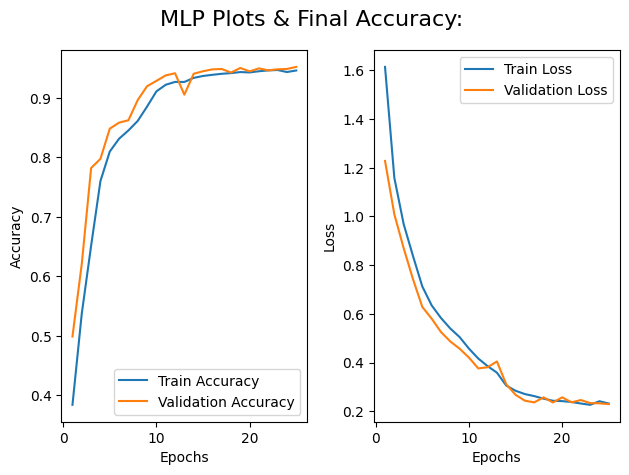

Accuracy of MLP: 0.94, Loss of MLP: 0.271


In [ ]:
# -- MLP plots & accuracy --
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

x_values = np.arange(1, len(train_accuracy) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("MLP Plots & Final Accuracy: ", fontsize=16)
ax1.plot(x_values, train_accuracy, label="Train Accuracy")
ax1.plot(x_values, val_accuracy, label="Validation Accuracy")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(x_values, train_loss, label="Train Loss")
ax2.plot(x_values, val_loss, label="Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()

fig.tight_layout()
plt.show()

print(f'Accuracy of MLP: {round(test_acc, 3)}, Loss of MLP: {round(test_loss, 3)}') 
# Using: eta=0.4, epochs=25


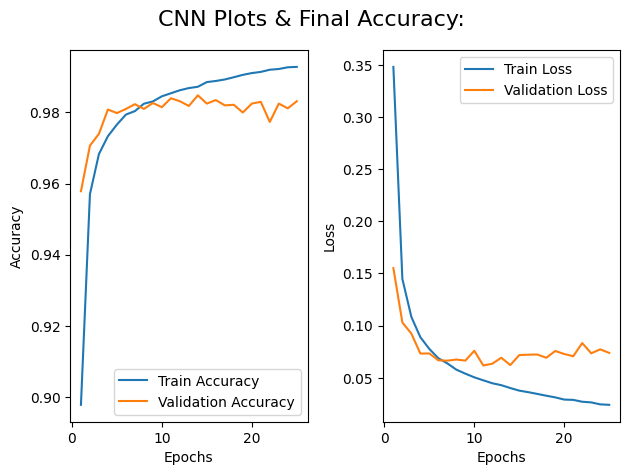

Accuracy of CNN: 0.98, Loss of CNN: 0.071


In [ ]:
# -- CNN plots & accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

x_values = np.arange(1, len(train_accuracy) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("CNN Plots & Final Accuracy: ", fontsize=16)
ax1.plot(x_values, train_accuracy, label="Train Accuracy")
ax1.plot(x_values, val_accuracy, label="Validation Accuracy")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(x_values, train_loss, label="Train Loss")
ax2.plot(x_values, val_loss, label="Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()

fig.tight_layout()
plt.show()

print(f'Accuracy of CNN: {round(test_acc, 3)}, Loss of CNN: {round(test_loss, 3)}') 
# 0.976 og 0.081 m: V. 0.4 og 25 epoker & 8 filter

Could probably have stopped training earlier, as validation loss seems to have plateaued(danger of overfit).